In [ ]:
eda = pd.read_csv('desafio_nps_fase_1.csv')

### 1. Categorizando o NPS
Primeiro, vamos categorizar a pontuação `nps_score` em Detratores (0-6), Passivos (7-8) e Promotores (9-10). Isso nos permitirá analisar o comportamento de diferentes grupos de clientes.

In [ ]:
def categorize_nps(score):
    if score >= 9:
        return 'Promoter'
    elif score >= 7:
        return 'Passive'
    else:
        return 'Detractor'

eda['nps_category'] = eda['nps_score'].apply(categorize_nps)
display(eda['nps_category'].value_counts(normalize=True).mul(100).round(2).astype(str) + '%')

,proportion
nps_category,
Detractor,84.36%
Passive,11.24%
Promoter,4.4%


### 2. Análise de Correlação com a Pontuação NPS
Vamos calcular a correlação entre as variáveis numéricas e a `nps_score` para identificar quais fatores têm maior impacto.

,Correlation with NPS Score
repeat_purchase_30d,0.570324
csat_internal_score,0.563952
order_value,0.036990
delivery_attempts,0.027680
discount_value,0.025104
payment_installments,0.023718
items_quantity,0.011468
delivery_time_days,0.000925
customer_tenure_months,-0.009711
customer_age,-0.009936


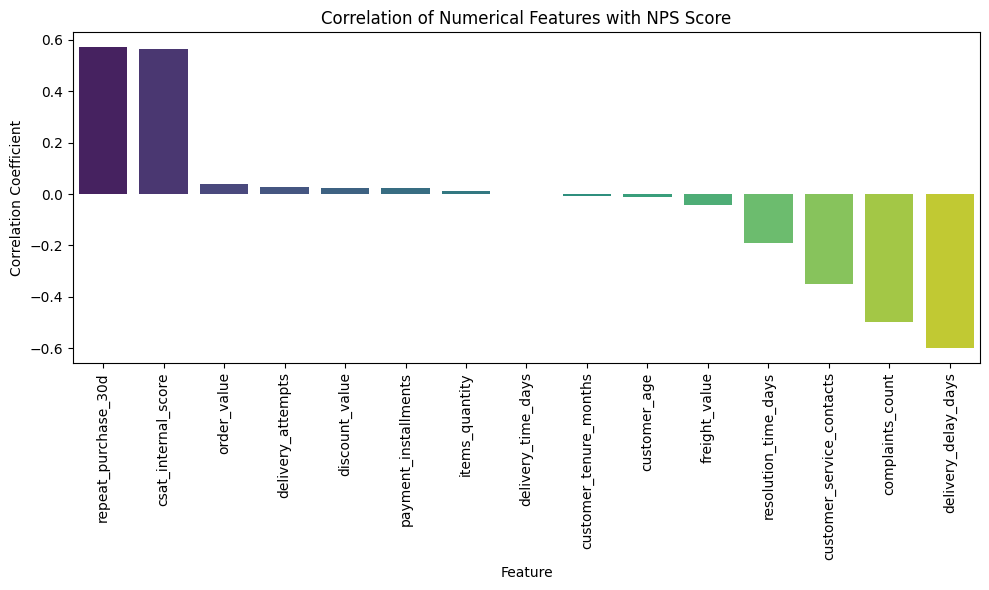

In [ ]:
# Selecionar colunas numéricas relevantes, excluindo IDs
numerical_cols = eda.select_dtypes(include=np.number).columns.tolist()
cols_for_corr = [col for col in numerical_cols if col not in ['customer_id', 'order_id', 'nps_score']]

# Calcular a correlação com nps_score
correlation_with_nps = eda[cols_for_corr + ['nps_score']].corr()['nps_score'].drop('nps_score').sort_values(ascending=False)
display(correlation_with_nps.to_frame(name='Correlation with NPS Score'))

plt.figure(figsize=(10, 6))
sns.barplot(x=correlation_with_nps.index, y=correlation_with_nps.values, palette='viridis')
plt.title('Correlation of Numerical Features with NPS Score')
plt.xlabel('Feature')
plt.ylabel('Correlation Coefficient')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

### 3. Comparando Métricas Chave por Categoria NPS
Agora, vamos analisar a média de algumas métricas importantes para cada categoria de NPS (Detrator, Passivo, Promotor). Isso nos ajudará a entender as diferenças de comportamento e experiência entre esses grupos.

In [ ]:
nps_impact_metrics = [
    'delivery_delay_days',
    'resolution_time_days',
    'customer_service_contacts',
    'complaints_count',
    'order_value',
    'freight_value',
    'customer_tenure_months'
]

nps_summary = eda.groupby('nps_category')[nps_impact_metrics].mean().round(2)
display(nps_summary.loc[['Detractor', 'Passive', 'Promoter']])

,delivery_delay_days,resolution_time_days,customer_service_contacts,complaints_count,order_value,freight_value,customer_tenure_months
nps_category,,,,,,,
Detractor,2.41,5.69,1.63,4.44,429.31,38.30,61.43
Passive,1.05,4.62,1.01,2.69,458.17,38.06,59.83
Promoter,0.72,3.70,0.67,2.27,468.08,37.05,63.00


### 4. Visualizando Fatores Críticos por Categoria NPS
Vamos criar box plots para visualizar a distribuição de algumas das métricas mais impactantes (identificadas acima) para cada categoria de NPS. Isso revelará visualmente as diferenças entre Detratores, Passivos e Promotores.

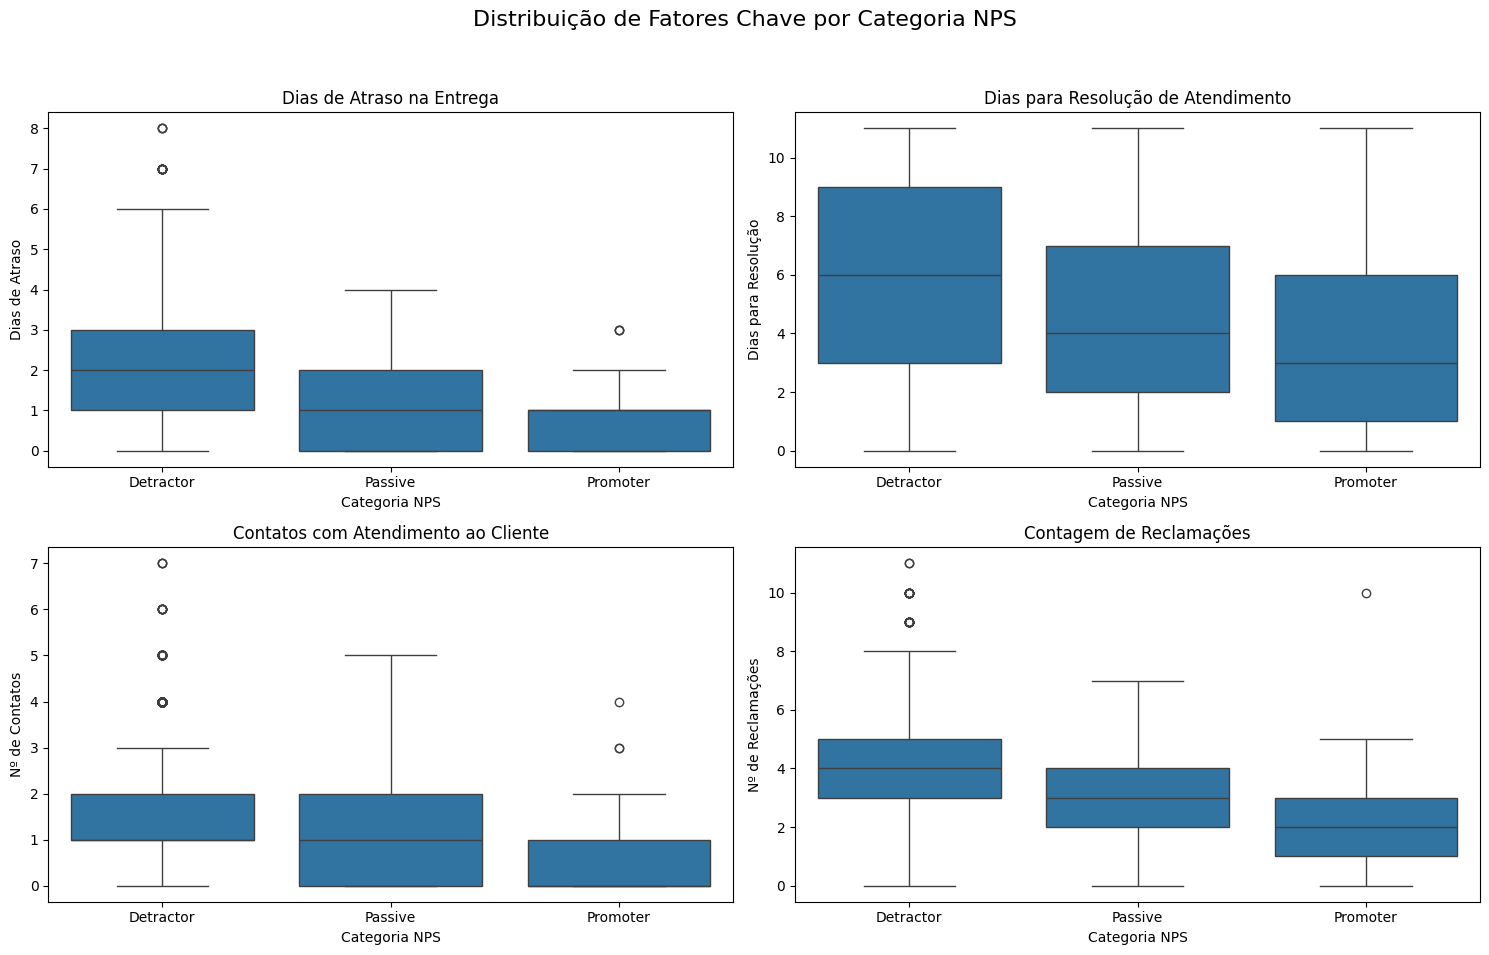

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Distribuição de Fatores Chave por Categoria NPS', fontsize=16)

sns.boxplot(x='nps_category', y='delivery_delay_days', data=eda, ax=axes[0, 0], order=['Detractor', 'Passive', 'Promoter'])
axes[0, 0].set_title('Dias de Atraso na Entrega')
axes[0, 0].set_xlabel('Categoria NPS')
axes[0, 0].set_ylabel('Dias de Atraso')

sns.boxplot(x='nps_category', y='resolution_time_days', data=eda, ax=axes[0, 1], order=['Detractor', 'Passive', 'Promoter'])
axes[0, 1].set_title('Dias para Resolução de Atendimento')
axes[0, 1].set_xlabel('Categoria NPS')
axes[0, 1].set_ylabel('Dias para Resolução')

sns.boxplot(x='nps_category', y='customer_service_contacts', data=eda, ax=axes[1, 0], order=['Detractor', 'Passive', 'Promoter'])
axes[1, 0].set_title('Contatos com Atendimento ao Cliente')
axes[1, 0].set_xlabel('Categoria NPS')
axes[1, 0].set_ylabel('Nº de Contatos')

sns.boxplot(x='nps_category', y='complaints_count', data=eda, ax=axes[1, 1], order=['Detractor', 'Passive', 'Promoter'])
axes[1, 1].set_title('Contagem de Reclamações')
axes[1, 1].set_xlabel('Categoria NPS')
axes[1, 1].set_ylabel('Nº de Reclamações')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

### 5. Análise de Região por Categoria NPS
Para variáveis categóricas como `customer_region`, podemos verificar a distribuição das categorias NPS para entender se há alguma região com desempenho significativamente diferente.

nps_category,Detractor,Passive,Promoter
customer_region,,,
Nordeste,0.856,0.101,0.043
Norte,0.852,0.113,0.036
Centro-Oeste,0.842,0.105,0.053
Sudeste,0.837,0.119,0.044
Sul,0.833,0.123,0.044


<Figure size 1200x700 with 0 Axes>

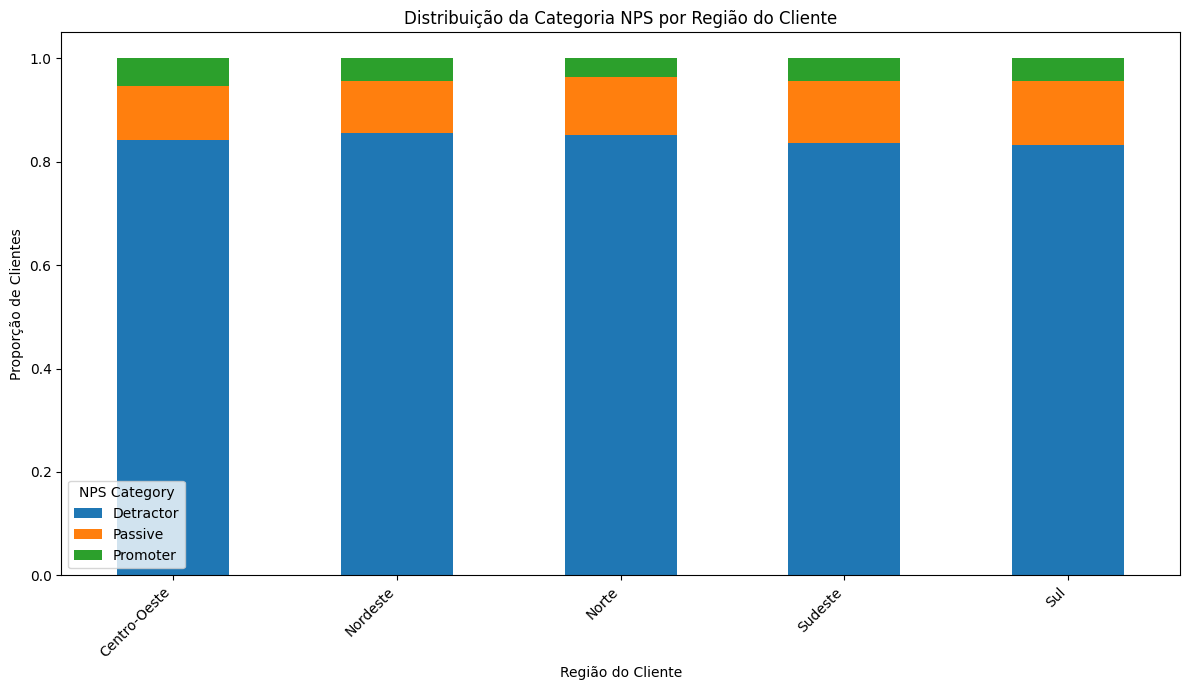

In [ ]:
region_nps_distribution = eda.groupby('customer_region')['nps_category'].value_counts(normalize=True).unstack().fillna(0)

# Ordenar pela proporção de Detratores para identificar regiões críticas
display(region_nps_distribution.sort_values(by='Detractor', ascending=False).round(3))

plt.figure(figsize=(12, 7))
region_nps_distribution.plot(kind='bar', stacked=True, figsize=(12, 7))
plt.title('Distribuição da Categoria NPS por Região do Cliente')
plt.ylabel('Proporção de Clientes')
plt.xlabel('Região do Cliente')
plt.xticks(rotation=45, ha='right')
plt.legend(title='NPS Category')
plt.tight_layout()
plt.show()

Com base nessas análises, os fatores críticos que impactam o negócio são likely relacionados a:

*   **Atrasos na Entrega (`delivery_delay_days`):** Detratores e Passivos parecem ter significativamente mais dias de atraso na entrega.
*   **Tempo de Resolução do Atendimento (`resolution_time_days`):** Tempos de resolução mais longos estão associados a clientes menos satisfeitos.
*   **Contatos com Atendimento ao Cliente (`customer_service_contacts`):** Um número maior de contatos com o atendimento pode indicar problemas não resolvidos ou dificuldade em obter suporte, levando à insatisfação.
*   **Contagem de Reclamações (`complaints_count`):** Naturalmente, um maior número de reclamações está fortemente correlacionado com Detratores.
*   **Valor do Pedido (`order_value`):** Embora a correlação seja menor, pode haver nuances na relação com o valor do pedido e a expectativa do cliente.
*   **Região do Cliente (`customer_region`):** As regiões com maior proporção de Detratores (ex: Nordeste, Sul) podem ter problemas específicos que precisam ser investigados.